In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import seaborn as sns


In [2]:
#pip install xgboost
from google.colab import files
uploaded = files.upload()

Saving Data_PEI_2019-2023.xlsx to Data_PEI_2019-2023.xlsx


In [3]:

# Load the dataset
df1 = pd.read_excel("Data_PEI_2019-2023.xlsx")



In [4]:
df1.head()

,Province,Location,Week Number,Crop Disease,Spore Trapping,DSI,Date,Year,Month,Temp,Dew Point Temp,Rel Hum,Precipitation,Wind Dir,Wind Spd
0,PEI,Field 2,29,Early Blight,16,1,2019-07-21,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
1,PEI,Field 2,29,Gray Mold,0,0,2019-07-21,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
2,PEI,Field 2,30,Early Blight,16,1,2019-07-28,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
3,PEI,Field 2,30,Gray Mold,0,0,2019-07-28,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
4,PEI,Field 2,31,Early Blight,49,1,2019-08-04,2019,8,22.401786,17.655357,75.333333,0.0,23.351190,18.976190


In [5]:
df1 = df1[df1['Crop Disease'] == 'Gray Mold']

In [6]:
df1.head()

,Province,Location,Week Number,Crop Disease,Spore Trapping,DSI,Date,Year,Month,Temp,Dew Point Temp,Rel Hum,Precipitation,Wind Dir,Wind Spd
1,PEI,Field 2,29,Gray Mold,0,0,2019-07-21,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
3,PEI,Field 2,30,Gray Mold,0,0,2019-07-28,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
5,PEI,Field 2,31,Gray Mold,1,1,2019-08-04,2019,8,22.401786,17.655357,75.333333,0.0,23.351190,18.976190
7,PEI,Field 2,32,Gray Mold,0,0,2019-08-11,2019,8,19.833333,15.702976,77.660714,0.0,21.273810,19.863095
9,PEI,Field 2,33,Gray Mold,0,0,2019-08-18,2019,8,19.489286,15.831548,79.880952,0.0,21.023810,16.178571


In [7]:
# Encode categorical variables
df1['Crop Disease'] = df1['Crop Disease'].astype("category").cat.codes
df1['Location'] = df1['Location'].astype("category").cat.codes


In [8]:

# Ensure the "Date" column is valid for conversion
df1["Date"] = pd.to_datetime(df1["Date"], errors='coerce')
if df1["Date"].isna().any():
    print("Invalid dates found:")
    print(df1[df1["Date"].isna()])



Class distribution in target variable:
DSI
1    688
0     53
Name: count, dtype: int64


<Axes: xlabel='DSI', ylabel='count'>

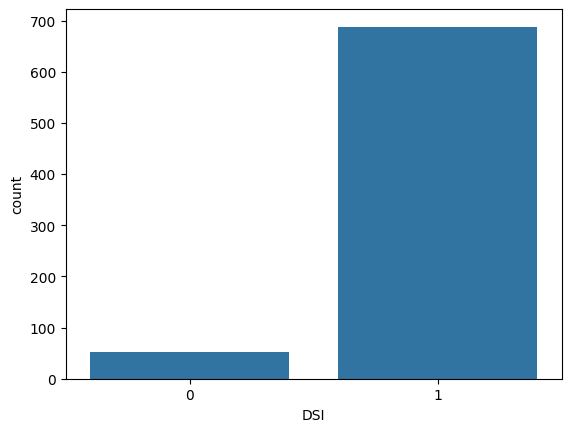

In [9]:
# Drop the "Date" column
df1 = df1.drop(["Date"], axis=1)

# Separate features and target variable
X = df1.drop(['DSI','Crop Disease', 'Province', 'Spore Trapping','Year'], axis=1)
y = df1['DSI']

# Check class distribution
print("Class distribution in target variable:")
print(y.value_counts())
sns.countplot(x=y)



In [10]:
df1.head()

,Province,Location,Week Number,Crop Disease,Spore Trapping,DSI,Year,Month,Temp,Dew Point Temp,Rel Hum,Precipitation,Wind Dir,Wind Spd
1,PEI,11,29,0,0,0,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
3,PEI,11,30,0,0,0,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
5,PEI,11,31,0,1,1,2019,8,22.401786,17.655357,75.333333,0.0,23.351190,18.976190
7,PEI,11,32,0,0,0,2019,8,19.833333,15.702976,77.660714,0.0,21.273810,19.863095
9,PEI,11,33,0,0,0,2019,8,19.489286,15.831548,79.880952,0.0,21.023810,16.178571


In [11]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify shapes
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

# Standard scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


Training data: (592, 9), Testing data: (149, 9)


In [ ]:

# Random Forest Classifier (baseline)
r = RandomForestClassifier(random_state=42, n_estimators=1000)
r.fit(X_train, y_train)
y_pred = r.predict(X_test)



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.27      0.38        11
           1       0.94      0.99      0.96       138

    accuracy                           0.93       149
   macro avg       0.77      0.63      0.67       149
weighted avg       0.92      0.93      0.92       149

Confusion Matrix (Random Forest):


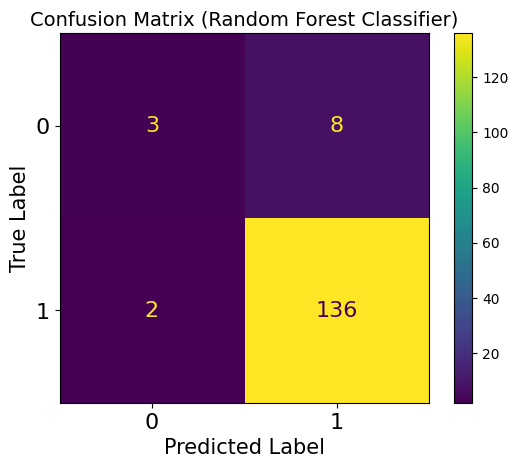

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# # Initialize and train Random Forest
# rf_model = RandomForestClassifier(random_state=42)
# rf_model.fit(X_train, y_train)

# # Make predictions
# y_pred_rf = rf_model.predict(X_test)

# Evaluation: Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix (Random Forest Classifier)", fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
for labels in disp_rf.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()



In [ ]:
disease_accuracy = accuracy_score(y_test, y_pred)
print(disease_accuracy)
from sklearn.metrics import precision_score, recall_score, f1_score
disease_precision = precision_score(y_test, y_pred, average='binary')
print(f"Precision: {disease_precision}")
disease_recall = recall_score(y_test, y_pred, average='binary')
print(f"Recall: {disease_recall}")
disease_f1 = f1_score(y_test, y_pred, average='binary')
print(f"F1-Score: {disease_f1}")

0.9328859060402684
Precision: 0.9444444444444444
Recall: 0.9855072463768116
F1-Score: 0.9645390070921985


In [ ]:

# Hyperparameter tuning for XGBoost
from sklearn.model_selection import GridSearchCV
# param grid: defines the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300], #number of trees in XGboost
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1, 2]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1  #n_jobs=-1: Utilizes all available CPU cores for parallel processing.
)
grid_search.fit(X_train, y_train)
print("Best Parameters (XGBoost):", grid_search.best_params_)



Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 2, 'subsample': 0.8}


In [ ]:
# Train XGBoost with best parameters
xgb = XGBClassifier(random_state=42, **grid_search.best_params_)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



XGBoost Accuracy: 0.9395973154362416
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.36      0.47        11
           1       0.95      0.99      0.97       138

    accuracy                           0.94       149
   macro avg       0.81      0.67      0.72       149
weighted avg       0.93      0.94      0.93       149



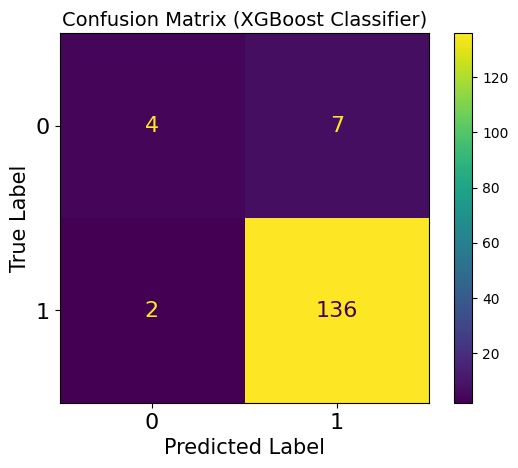

In [ ]:
# # Evaluation: XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("Confusion Matrix (XGBoost Classifier)", fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
for labels in disp_xgb.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()

In [ ]:

# Cross-validation with stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (XGBoost):", cv_scores.mean())


Cross-Validation Accuracy (XGBoost): 0.9554598222383456


In [ ]:
cv_scores = cross_val_score(r, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (random):", cv_scores.mean())

Cross-Validation Accuracy (random): 0.9514329766007619


In [ ]:

# # Feature importance visualization (XGBoost)
# from xgboost import plot_importance
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# plot_importance(xgb)
# plt.title("Feature Importance (XGBoost)")
# plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



GaussianNB Classifier:
TSImple Model est Accuracy: 0.9329
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.18      0.29        11
           1       0.94      0.99      0.96       138

    accuracy                           0.93       149
   macro avg       0.80      0.59      0.63       149
weighted avg       0.92      0.93      0.91       149



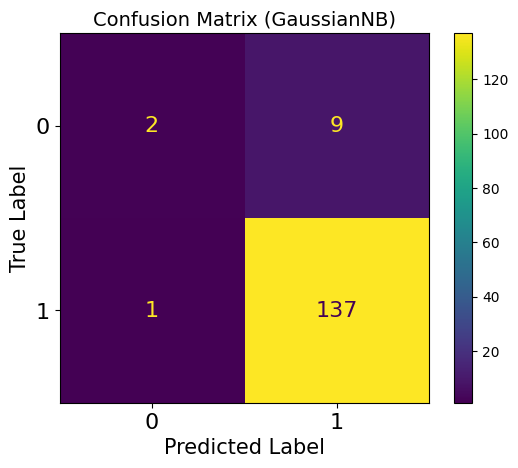

accuracy 0.9328859060402684
Cross-Validation Precision: 0.9383561643835616
Cross-Validation Recall: 0.9927536231884058
Cross-Validation F1-Score: 0.9647887323943662
Cross-Validation Metrics (5 folds):
Accuracy: 0.9258 ± 0.0105

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.9128
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.18      0.24        11
           1       0.94      0.97      0.95       138

    accuracy                           0.91       149
   macro avg       0.64      0.58      0.59       149
weighted avg       0.89      0.91      0.90       149



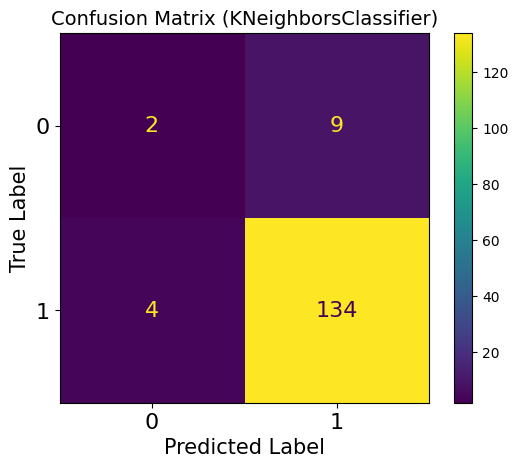

accuracy 0.912751677852349
Cross-Validation Precision: 0.9370629370629371
Cross-Validation Recall: 0.9710144927536232
Cross-Validation F1-Score: 0.9537366548042705
Cross-Validation Metrics (5 folds):
Accuracy: 0.9109 ± 0.0168

Decision Tree Classifier Classifier:
TSImple Model est Accuracy: 0.8926
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.45      0.38        11
           1       0.96      0.93      0.94       138

    accuracy                           0.89       149
   macro avg       0.64      0.69      0.66       149
weighted avg       0.91      0.89      0.90       149



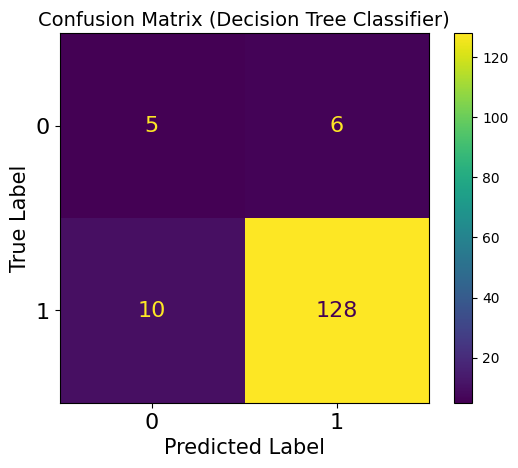

accuracy 0.8926174496644296
Cross-Validation Precision: 0.9552238805970149
Cross-Validation Recall: 0.927536231884058
Cross-Validation F1-Score: 0.9411764705882353
Cross-Validation Metrics (5 folds):
Accuracy: 0.9420 ± 0.0140

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.9262
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.93      1.00      0.96       138

    accuracy                           0.93       149
   macro avg       0.46      0.50      0.48       149
weighted avg       0.86      0.93      0.89       149



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


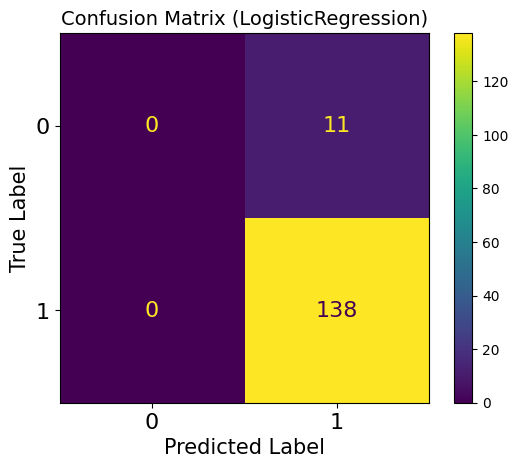

accuracy 0.9261744966442953
Cross-Validation Precision: 0.9261744966442953
Cross-Validation Recall: 1.0
Cross-Validation F1-Score: 0.9616724738675958
Cross-Validation Metrics (5 folds):
Accuracy: 0.9271 ± 0.0027


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors
# svc = SVC(kernel='rbf', random_state=42)  # Default kernel: RBF
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    "Decision Tree Classifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})", fontsize=14)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Predicted Label", fontsize=15)
    plt.ylabel("True Label", fontsize=15)
    # Adjust inside label font size
    for labels in disp.text_:  # Update text labels
        for label in labels:
            label.set_fontsize(16)
    # plt.show()
     # Confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
    # disp.plot(ax=ax, cmap='viridis', colorbar=False)
    # plt.title(f"Confusion Matrix ({name})", fontsize=16)
    # plt.xticks(fontsize=14)
    # plt.yticks(fontsize=14)

    # # Adjust inside label font size
    # for labels in disp.text_:  # Update text labels
    #     for label in labels:
    #         label.set_fontsize(18)



    plt.show()

    disease_accuracy = accuracy_score(y_test, y_pred)
    print("accuracy", disease_accuracy)
    # Precision, Recall, and F1-Score without cross-validation
    precision_scores = precision_score(y_test, y_pred, average='binary')
    print("Cross-Validation Precision:", precision_scores)

    recall_scores = recall_score(y_test, y_pred, average='binary')
    print("Cross-Validation Recall:", recall_scores)

    f1_scores = f1_score(y_test, y_pred, average='binary')
    print("Cross-Validation F1-Score:", f1_scores)

    # Perform cross-validation for multiple metrics
    accuracy_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Metrics ({n_splits} folds):")
    print(f"Accuracy: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")


GaussianNB Classifier:
TSImple Model est Accuracy: 0.9329
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.18      0.29        11
           1       0.94      0.99      0.96       138

    accuracy                           0.93       149
   macro avg       0.80      0.59      0.63       149
weighted avg       0.92      0.93      0.91       149



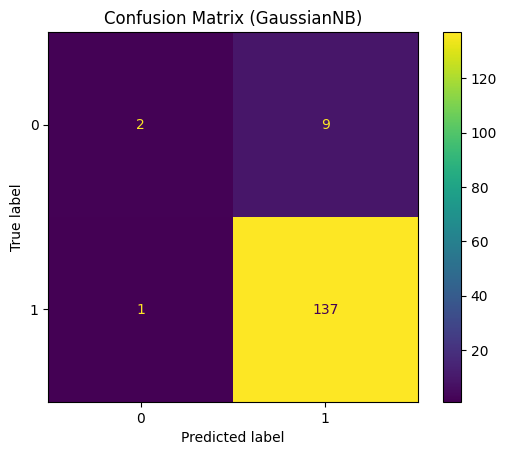

Cross-Validation Accuracy (5 folds): 0.9258 ± 0.0105

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.9128
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.18      0.24        11
           1       0.94      0.97      0.95       138

    accuracy                           0.91       149
   macro avg       0.64      0.58      0.59       149
weighted avg       0.89      0.91      0.90       149



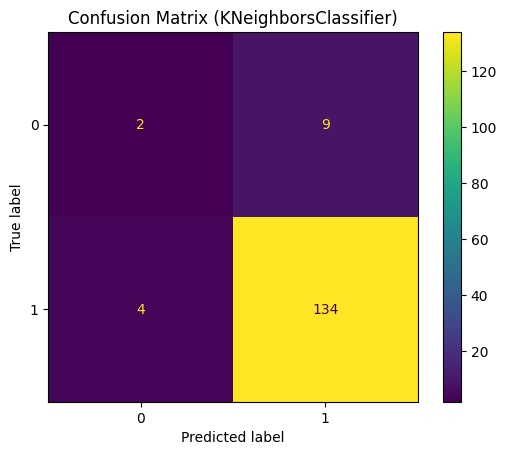

Cross-Validation Accuracy (5 folds): 0.9109 ± 0.0168

DecisionTreeClassifier Classifier:
TSImple Model est Accuracy: 0.8926
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.45      0.38        11
           1       0.96      0.93      0.94       138

    accuracy                           0.89       149
   macro avg       0.64      0.69      0.66       149
weighted avg       0.91      0.89      0.90       149



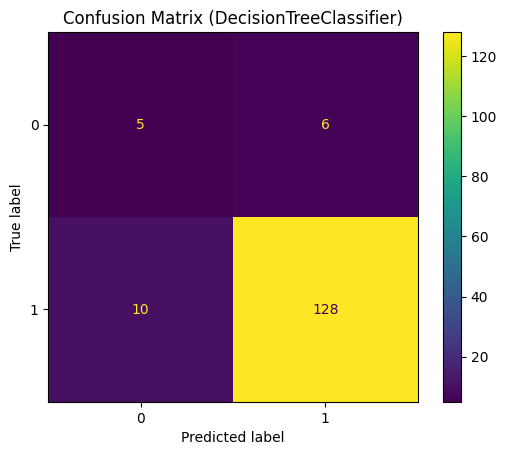

Cross-Validation Accuracy (5 folds): 0.9420 ± 0.0140

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.9262
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.93      1.00      0.96       138

    accuracy                           0.93       149
   macro avg       0.46      0.50      0.48       149
weighted avg       0.86      0.93      0.89       149



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


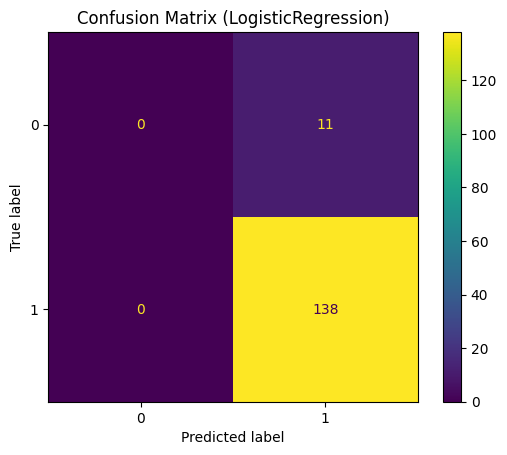

Cross-Validation Accuracy (5 folds): 0.9271 ± 0.0027


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors
# svc = SVC(kernel='rbf', random_state=42)  # Default kernel: RBF
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    # "SVC": svc,
    "DecisionTreeClassifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    # Perform cross-validation
    cv_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Accuracy ({n_splits} folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
